## Xử lý dữ liệu cho LLM

In [ ]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from items import Item
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt


In [ ]:
from google.colab import userdata
LITE_MODE = False
hf_token = userdata.get('HF_TOKEN')

login(hf_token, add_to_git_credential=True)

In [ ]:
username = "SeanSunny"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

README.md:   0%|          | 0.00/744 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/3.08M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/3.09M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Loaded 800,000 training items, 10,000 validation items, 10,000 test items


In [ ]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

In [ ]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

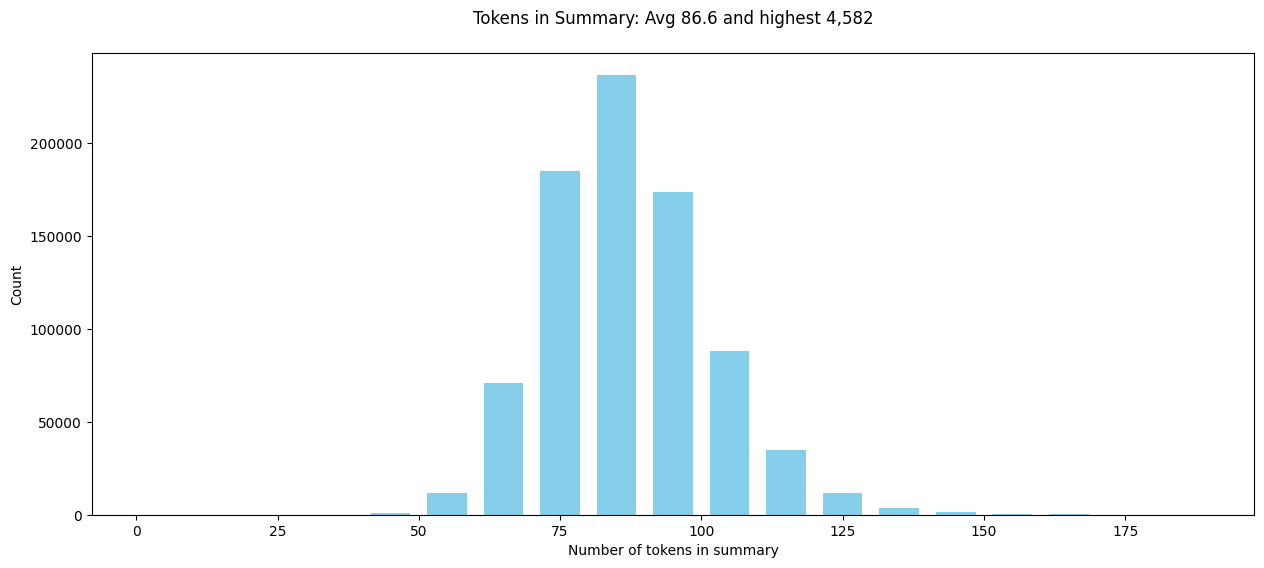

In [ ]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

In [ ]:
print(items[0].summary)

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.


In [ ]:
print(train[0].summary)

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.


In [ ]:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")


With this CUTOFF, we will truncate 47,083 items which is 5.7%


In [ ]:
print(train[0].summary)

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.


In [ ]:
for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF, True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, False)

  0%|          | 0/810000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
print(train[0].prompt)

What does this cost to the nearest dollar?

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.

Price is $


In [ ]:
print(train[1].completion)

79.00


In [ ]:
print("PROMPT:")
print(test[1].prompt)
print("COMPLETION:")
print(test[1].completion)


PROMPT:
What does this cost to the nearest dollar?

Title: Telpo Headlight Assembly for 2015‑2017 Toyota Camry  
Category: Automotive Accessories  
Brand: Telpo  
Description: Dual headlight assembly that fits the 2015‑2017 Toyota Camry front driver and passenger sides.  
Details: Direct replacement with DOT & SAE‑certified lenses, high/low beam, waterproof construction, and a 1‑year limited warranty.

Price is $
COMPLETION:
115.99


In [ ]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

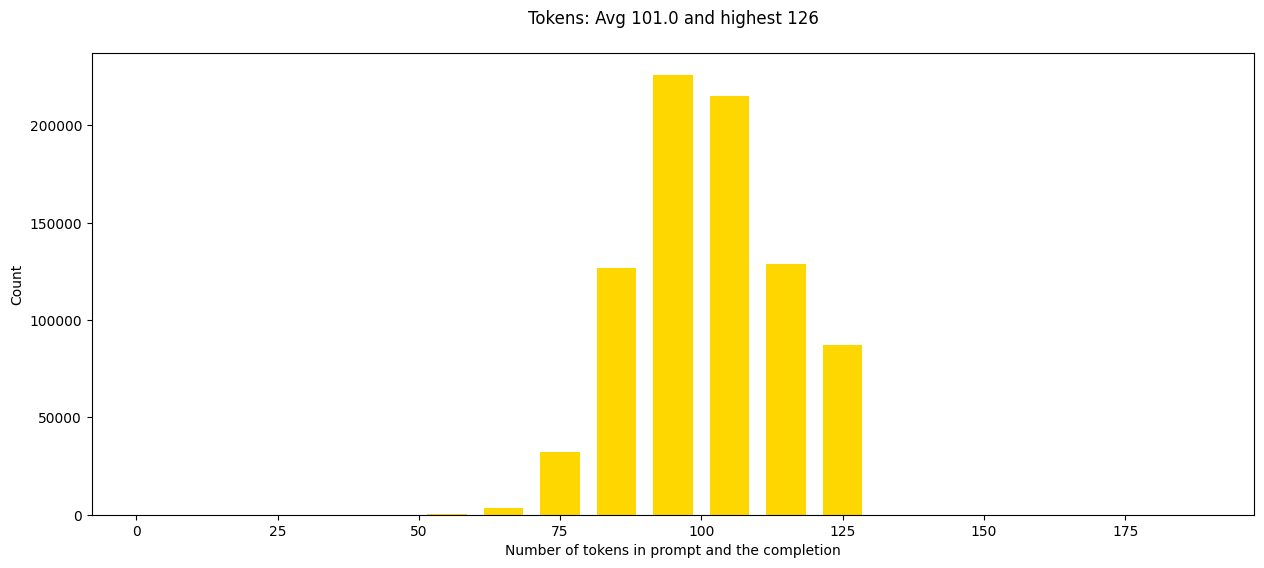

In [ ]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 200, 10))
plt.show()

## Chọn model

In [ ]:
!pip install -q --upgrade bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 6.8 MB/s eta 0:00:00


In [ ]:
# imports

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, set_seed
from peft import LoraConfig, PeftModel
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
import matplotlib.pyplot as plt
from evaluator import evaluate

In [ ]:
LLAMA_3_2 = "meta-llama/Llama-3.2-3B"
QWEN_2_5 = "Qwen/Qwen2.5-7B"
GEMMA_2 = "google/gemma-2-9b"
PHI_3 = "microsoft/Phi-3-medium-4k-instruct"

In [ ]:
# Log in to HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
def investigate_tokenizer(model_name):
  print("Investigating tokenizer for", model_name)
  tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
  for number in [0, 1, 10, 100, 999, 1000]:
    tokens = tokenizer.encode(str(number), add_special_tokens=False)
    print(f"The tokens for {number}: {tokens}")

In [ ]:
investigate_tokenizer(PHI_3)

Investigating tokenizer for microsoft/Phi-3-medium-4k-instruct
The tokens for 0: [29871, 29900]
The tokens for 1: [29871, 29896]
The tokens for 10: [29871, 29896, 29900]
The tokens for 100: [29871, 29896, 29900, 29900]
The tokens for 999: [29871, 29929, 29929, 29929]
The tokens for 1000: [29871, 29896, 29900, 29900, 29900]


In [ ]:
investigate_tokenizer(LLAMA_3_2)

Investigating tokenizer for meta-llama/Llama-3.2-3B
The tokens for 0: [15]
The tokens for 1: [16]
The tokens for 10: [605]
The tokens for 100: [1041]
The tokens for 999: [5500]
The tokens for 1000: [1041, 15]


In [ ]:
investigate_tokenizer(QWEN_2_5)

Investigating tokenizer for Qwen/Qwen2.5-7B


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

The tokens for 0: [15]
The tokens for 1: [16]
The tokens for 10: [16, 15]
The tokens for 100: [16, 15, 15]
The tokens for 999: [24, 24, 24]
The tokens for 1000: [16, 15, 15, 15]


In [ ]:
investigate_tokenizer(GEMMA_2)

Investigating tokenizer for google/gemma-2-9b


tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

The tokens for 0: [235276]
The tokens for 1: [235274]
The tokens for 10: [235274, 235276]
The tokens for 100: [235274, 235276, 235276]
The tokens for 999: [235315, 235315, 235315]
The tokens for 1000: [235274, 235276, 235276, 235276]


## QLORA

In [ ]:
!pip install -q --upgrade bitsandbytes

In [ ]:
# imports

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, set_seed
from peft import LoraConfig, PeftModel
from datetime import datetime

In [ ]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

In [ ]:
# Log in to HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL, device_map="auto")

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [ ]:
print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:,.1f} GB")

Memory footprint: 12.9 GB


In [ ]:
base_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (

In [ ]:
# Load the Tokenizer and the Base Model using 4 bit

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4")

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:,.2f} GB")

Memory footprint: 2.20 GB


In [ ]:
base_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear4bit(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNo

In [ ]:
# Each of the Target Modules has 2 LoRA Adaptor matrices, called lora_A and lora_B
# These are designed so that weights can be adapted by adding alpha * lora_A * lora_B
# Let's count the number of weights using their dimensions:

r = 32

# See the matrix dimensions above

# Attention layers
lora_q_proj = 3072 * r + 3072 * r
lora_k_proj = 3072 * r + 1024 * r
lora_v_proj = 3072 * r + 1024 * r
lora_o_proj = 3072 * r + 3072 * r

# Each layer comes to
lora_layer = lora_q_proj + lora_k_proj + lora_v_proj + lora_o_proj

# There are 28 layers
params = lora_layer * 28

# So the total size in MB is
size = (params * 4) / 1_000_000

print(f"Total number of params: {params:,} and size {size:,.1f}MB")

Total number of params: 18,350,080 and size 73.4MB


In [ ]:
# Each of the Target Modules has 2 LoRA Adaptor matrices, called lora_A and lora_B
# These are designed so that weights can be adapted by adding alpha * lora_A * lora_B
# Let's count the number of weights using their dimensions:

r = 256

# See the matrix dimensions above

# Attention layers
lora_q_proj = 3072 * r + 3072 * r
lora_k_proj = 3072 * r + 1024 * r
lora_v_proj = 3072 * r + 1024 * r
lora_o_proj = 3072 * r + 3072 * r

# MLP layers
lora_gate_proj = 3072 * r + 8192 * r
lora_up_proj = 3072 * r + 8192 * r
lora_down_proj = 3072 * r + 8192 * r

# Each layer comes to
lora_layer = lora_q_proj + lora_k_proj + lora_v_proj + lora_o_proj + lora_gate_proj + lora_up_proj + lora_down_proj

# There are 28 layers
params = lora_layer * 28

# So the total size in MB is
size = (params * 4) / 1_000_000

print(f"Total number of params: {params:,} and size {size:,.1f}MB")

Total number of params: 389,021,696 and size 1,556.1MB


## Test Base Model

In [ ]:
!pip install -q --upgrade bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.5 MB/s eta 0:00:00


In [ ]:
# imports

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, set_seed
from peft import LoraConfig, PeftModel
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
import matplotlib.pyplot as plt
from util import evaluate

In [ ]:
# Constants

BASE_MODEL = "meta-llama/Llama-3.2-3B"
PROJECT_NAME = "price"

LITE_MODE = True

DATA_USER = "SeanSunny"
DATASET_NAME = f"{DATA_USER}/items_prompts_lite" if LITE_MODE else f"{DATA_USER}/items_prompts_full"

# Hyper-parameters

QUANT_4_BIT = True

In [ ]:
# Log in to HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
val = dataset['val']
test = dataset['test']

README.md:   0%|          | 0.00/509 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/4.37M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/219k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/221k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
test[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $',
 'completion': '219.0'}

In [ ]:
test[0]["prompt"]

'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $'

In [ ]:
train[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  \nCategory: Home Hardware  \nBrand: Schlage  \nDescription: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  \nDetails: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.\n\nPrice is $',
 'completion': '64.00'}

In [ ]:
## pick the right quantization

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16
  )

In [ ]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:.1f} GB")

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Memory footprint: 2.2 GB


In [ ]:
def model_predict(item):
    inputs = tokenizer(item["prompt"],return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_ids = base_model.generate(**inputs, max_new_tokens=8)
    prompt_len = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0, prompt_len:]
    return tokenizer.decode(generated_ids)

In [ ]:
test[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $',
 'completion': '219.0'}

In [ ]:
model_predict(test[0])

'99.00 USD. The pedal is'

In [ ]:
evaluate(model_predict, test)

## Training

In [ ]:
!pip install -q --upgrade bitsandbytes==0.48.2 trl==0.25.1

In [ ]:
import os
import re
import math
from tqdm import tqdm
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, set_seed, BitsAndBytesConfig
from datasets import load_dataset, Dataset, DatasetDict
import wandb
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from datetime import datetime
import matplotlib.pyplot as plt

In [ ]:
# Constants

BASE_MODEL = "meta-llama/Llama-3.2-3B"
PROJECT_NAME = "price-v2-gpu3090ti-vast"
HF_USER = "SeanSunny"

LITE_MODE = False

DATA_USER = "SeanSunny"
DATASET_NAME = f"{DATA_USER}/items_prompts_lite" if LITE_MODE else f"{DATA_USER}/items_prompts_full"

RUN_NAME =  f"{datetime.now():%Y-%m-%d_%H.%M.%S}"
if LITE_MODE:
  RUN_NAME += "-lite"
PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"
HUB_MODEL_NAME = f"{HF_USER}/{PROJECT_RUN_NAME}"

# Hyper-parameters - overall

EPOCHS = 1 if LITE_MODE else 3
BATCH_SIZE = 32 if LITE_MODE else 16
MAX_SEQUENCE_LENGTH = 128
GRADIENT_ACCUMULATION_STEPS = 1 if LITE_MODE else 4

# Hyper-parameters - QLoRA

QUANT_4_BIT = True
LORA_R = 32 if LITE_MODE else 64
LORA_ALPHA = LORA_R * 2
ATTENTION_LAYERS = ["q_proj", "v_proj", "k_proj", "o_proj"]
MLP_LAYERS = ["gate_proj", "up_proj", "down_proj"]
TARGET_MODULES = ATTENTION_LAYERS if LITE_MODE else ATTENTION_LAYERS + MLP_LAYERS
LORA_DROPOUT = 0.1

# Hyper-parameters - training

LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.03
LR_SCHEDULER_TYPE = 'cosine'
WEIGHT_DECAY = 0.001
OPTIMIZER = "paged_adamw_32bit"

capability = torch.cuda.get_device_capability()
use_bf16 = capability[0] >= 8

# Tracking

VAL_SIZE = 500 if LITE_MODE else 1000
LOG_STEPS = 5 if LITE_MODE else 10
SAVE_STEPS = 100 if LITE_MODE else 200
LOG_TO_WANDB = True

In [ ]:
# Log in to HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
# Log in to Weights & Biases
wandb_api_key = userdata.get('WANDB_API_KEY')
os.environ["WANDB_API_KEY"] = wandb_api_key
wandb.login()

# Configure Weights & Biases to record against our project
os.environ["WANDB_PROJECT"] = PROJECT_NAME
os.environ["WANDB_LOG_MODEL"] = "false"
os.environ["WANDB_WATCH"] = "false"

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Currently logged in as: hieu0606sunny (hieu0606sunny-student) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
val = dataset['val'].select(range(VAL_SIZE))
test = dataset['test']

README.md:   0%|          | 0.00/509 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/4.37M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/219k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/221k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
if LOG_TO_WANDB:
  wandb.init(project=PROJECT_NAME, name=RUN_NAME)

In [ ]:
# pick the right quantization

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
  )

In [ ]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"Memory footprint: {base_model.get_memory_footprint() / 1e6:.1f} MB")

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Memory footprint: 2197.6 MB


In [ ]:
# LoRA Parameters

lora_parameters = LoraConfig(
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    r=LORA_R,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=TARGET_MODULES,
)

In [ ]:
# Training parameters

train_parameters = SFTConfig(
    output_dir=PROJECT_RUN_NAME,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    optim=OPTIMIZER,
    save_steps=SAVE_STEPS,
    save_total_limit=10,
    logging_steps=LOG_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=0.001,
    fp16=not use_bf16,
    bf16=use_bf16,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=WARMUP_RATIO,
    group_by_length=True,
    lr_scheduler_type=LR_SCHEDULER_TYPE,
    report_to="wandb" if LOG_TO_WANDB else None,
    run_name=RUN_NAME,
    max_length=MAX_SEQUENCE_LENGTH,
    save_strategy="steps",
    hub_strategy="every_save",
    push_to_hub=True,
    hub_model_id=HUB_MODEL_NAME,
    hub_private_repo=True,
    eval_strategy="steps",
    eval_steps=SAVE_STEPS
)

In [ ]:
fine_tuning = SFTTrainer(
    model=base_model,
    train_dataset=train,
    eval_dataset=val,
    peft_config=lora_parameters,
    args=train_parameters
)

Adding EOS to train dataset:   0%|          | 0/20000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/20000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/20000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
# Fine-tune!
fine_tuning.train()

# Push our fine-tuned model to Hugging Face
fine_tuning.model.push_to_hub(PROJECT_RUN_NAME, private=True)
print(f"Saved to the hub: {PROJECT_RUN_NAME}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': None}.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,1.302900,1.289114,2.583617,330223.000000,0.756500
200,1.266000,1.269228,2.703636,659017.000000,0.759000
300,1.281700,1.274109,2.690107,988895.000000,0.762000
400,1.249500,1.255144,2.669782,1319755.000000,0.763000
500,1.238300,1.253343,2.670628,1649501.000000,0.761500
600,1.263900,1.247705,2.677110,1978536.000000,0.763000


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

README.md:   0%|          | 0.00/1.76k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  46%|####5     | 33.4MB / 73.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Saved to the hub: price-v2-gput4-2026-01-13_03.48.41-lite


In [ ]:
if LOG_TO_WANDB:
  wandb.finish()

eval/entropy,▁█▇▆▆▆
eval/loss,█▅▅▂▂▁
eval/mean_token_accuracy,▁▄▇█▆█
eval/num_tokens,▁▂▄▅▇█
eval/runtime,▃▃▂▁█▄
eval/samples_per_second,▆▆▆█▁▅
eval/steps_per_second,▆▆▆█▁▅
train/entropy,█▂▂▂▄▃▂▃▁▃▆▁▃▅▆▄▄▅▅▇▅▆█▅▅▆▆▄▅▇▅▇▃▄▆▂▅▅▆▃
train/epoch,▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██
train/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█
+5,...


In [ ]:
/content/price-v2-gput4-2026-01-13_03.48.41-lite

In [ ]:
# 1. Nén thư mục
# Thay 'ten_folder_cua_ban' bằng tên thư mục bạn thấy trong cột bên trái
# Thay 'file_nen.zip' bằng tên file bạn muốn đặt
!zip -r price-v2-gput4-2026-01-13_03.48.41-lite.zip price-v2-gput4-2026-01-13_03.48.41-lite

# 2. Tải về máy tính
from google.colab import files
files.download('price-v2-gput4-2026-01-13_03.48.41-lite.zip')

  adding: price-v2-gput4-2026-01-13_03.48.41-lite/ (stored 0%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/tokenizer.json (deflated 85%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/checkpoint-100/ (stored 0%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/checkpoint-100/tokenizer.json (deflated 85%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/checkpoint-100/trainer_state.json (deflated 75%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/checkpoint-100/rng_state.pth (deflated 26%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/checkpoint-100/optimizer.pt (deflated 8%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/checkpoint-100/special_tokens_map.json (deflated 62%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/checkpoint-100/adapter_config.json (deflated 57%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/checkpoint-100/README.md (deflated 65%)
  adding: price-v2-gput4-2026-01-13_03.48.41-lite/checkpoint-100/training_args.bin (deflated 53%)
  addin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## test model fine tune

In [ ]:
!pip install -q --upgrade bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 45.7 MB/s eta 0:00:00


In [ ]:
# imports

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
from peft import PeftModel
from util import evaluate

In [ ]:
# Constants

BASE_MODEL = "meta-llama/Llama-3.2-3B"
PROJECT_NAME = "price"
HF_USER = "SeanSunny" # your HF name here!

LITE_MODE = False

DATA_USER = "SeanSunny"
DATASET_NAME = f"{DATA_USER}/items_prompts_lite" if LITE_MODE else f"{DATA_USER}/items_prompts_full"

HUB_MODEL_NAME = f"{HF_USER}/price-2026-final"


# Hyper-parameters - QLoRA

QUANT_4_BIT = True
capability = torch.cuda.get_device_capability()
use_bf16 = capability[0] >= 8

In [ ]:
# Log in to HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
dataset = load_dataset(DATASET_NAME)
test = dataset['test']

README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/175M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/2.18M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.21M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800000 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
test[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $',
 'completion': '219.0'}

In [ ]:
# pick the right quantization

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
  )

In [ ]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id


fine_tuned_model = PeftModel.from_pretrained(base_model, HUB_MODEL_NAME)


print(f"Memory footprint: {fine_tuned_model.get_memory_footprint() / 1e6:.1f} MB")

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

Memory footprint: 3753.7 MB


In [ ]:
fine_tuned_model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 3072)
        (layers): ModuleList(
          (0-27): 28 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=256, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=256, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lo

In [ ]:
def model_predict(item):
    inputs = tokenizer(item["prompt"],return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_ids = fine_tuned_model.generate(**inputs, max_new_tokens=8)
    prompt_len = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0, prompt_len:]
    return tokenizer.decode(generated_ids)

In [ ]:
set_seed(42)
evaluate(model_predict, test)